In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./PhotonDetector/build/2mm_50um_bottom_1k_photon_boundaries.csv")
df.head()

,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,volumeName,x_mm,y_mm,z_mm,px,py,pz,kineticEnergy_MeV,time_s
0,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorNegX,-300.0,-47.9488,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0
1,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,exit,physPhotonDetectorNegX,-300.0,-47.9488,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0
2,0,2014,1856,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,300.0,17.3494,-45.6265,0.980583,0.026413,-0.194316,0.510028,590387.0
3,0,2014,1856,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physPhotonDetectorPosX,300.0,17.3494,-45.6265,0.980583,0.026413,-0.194316,0.510028,590387.0
4,1,2055,1613,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorNegX,-300.0,-11.3564,-51.0807,-0.980908,-0.192307,0.028953,0.042623,279175.0


In [9]:
df.groupby(['originIsotope', 'eventID']).count()

trackID  parentID  particleName  originCode  \
originIsotope eventID                                                
Bi210         60             2         2             2           2   
              75             2         2             2           2   
              77             2         2             2           2   
              89             2         2             2           2   
              148            2         2             2           2   
...                        ...       ...           ...         ...   
Po214         992            2         2             2           2   
              993            2         2             2           2   
              996            2         2             2           2   
              997            2         2             2           2   
              998            4         4             4           4   

                       originLabel  creatorProcess  boundary  volumeName  \
originIsotope eventID                                                      
Bi210         60                 2               2         2           2   
              75                 2               2         2           2   
              77                 2               2         2           2   
              89                 2               2         2           2   
              148                2               2         2           2   
...                            ...             ...       ...         ...   
Po214         992                2               2         2           2   
              993                2               2         2           2   
              996                2               2         2           2   
              997                2               2         2           2   
              998                4               4         4           4   

                       x_mm  y_mm  z_mm  px  py  pz  kineticEnergy_MeV  time_s  
originIsotope eventID                                                           
Bi210         60          2     2     2   2   2   2                  2       2  
              75          2     2     2   2   2   2                  2       2  
              77          2     2     2   2   2   2                  2       2  
              89          2     2     2   2   2   2                  2       2  
              148         2     2     2   2   2   2                  2       2  
...                     ...   ...   ...  ..  ..  ..                ...     ...  
Po214         992         2     2     2   2   2   2                  2       2  
              993         2     2     2   2   2   2                  2       2  
              996         2     2     2   2   2   2                  2       2  
              997         2     2     2   2   2   2                  2       2  
              998         4     4     4   4   4   4                  4       4  

[1075 rows x 16 columns]

In [5]:
df[(df['volumeName'].str.contains('physPhotonDetector'))&(df['boundary']=='enter')]

,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,volumeName,x_mm,y_mm,z_mm,px,py,pz,kineticEnergy_MeV,time_s
0,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorNegX,-300.0000,-47.94880,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0
2,0,2014,1856,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,300.0000,17.34940,-45.6265,0.980583,0.026413,-0.194316,0.510028,590387.0
4,1,2055,1613,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorNegX,-300.0000,-11.35640,-51.0807,-0.980908,-0.192307,0.028953,0.042623,279175.0
6,2,1806,1183,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorPosX,300.0000,-27.77910,159.7570,0.952624,-0.286261,-0.102772,0.047452,365031.0
8,3,1273,1177,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorNegX,-300.0000,-45.55270,-115.1310,-0.930288,-0.135573,-0.340858,0.136884,327355.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2736,997,1728,1500,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosY,-109.0240,300.00000,6.4527,-0.362502,0.931956,0.007019,2.204080,291706.0
2738,998,2559,1681,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorPosX,300.0000,-41.75500,-230.2880,0.686717,-0.084738,-0.721969,0.632425,651490.0
2740,998,2718,2558,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physPhotonDetectorNegY,33.9607,-300.00000,23.7510,-0.085529,-0.994351,0.062853,0.609315,651490.0
2742,999,1108,1100,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,physPhotonDetectorNegY,99.1391,-300.00000,-280.2020,0.372282,-0.689953,-0.620783,0.104036,176181.0


In [12]:
df['is_detector']=df['volumeName'].str.startswith('physPhotonDetector')

In [15]:
df['detector_face']=df['volumeName'].where(df['is_detector'], 'not_detector')

In [18]:
df[df['detector_face']=='not_detector']

,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,volumeName,x_mm,y_mm,z_mm,px,py,pz,kineticEnergy_MeV,time_s,is_detector,detector_face
80,32,1957,1240,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physGlue,-1.69774,100.0,3.65976,0.139936,0.987340,-0.074683,1.764510,381688.0,False,not_detector
81,32,1957,1240,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physGlue,-1.69774,100.0,3.65976,0.139936,0.987340,-0.074683,1.764510,381688.0,False,not_detector
98,39,2029,1534,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physGlue,3.70133,100.0,4.90133,0.087833,0.982184,0.166130,1.764510,449077.0,False,not_detector
99,39,2029,1534,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physGlue,3.70133,100.0,4.90133,0.087833,0.982184,0.166130,1.764510,449077.0,False,not_detector
104,41,2240,1605,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physWater,-23.81890,-100.0,-23.79640,-0.642267,0.760528,-0.095339,0.768361,399480.0,False,not_detector
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2717,989,1851,1848,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,physWater,-6.87864,100.0,-4.09545,-0.136591,-0.189044,0.972422,0.609315,486588.0,False,not_detector
2718,989,1851,1848,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physGlue,-5.43357,102.0,-14.38330,-0.136591,-0.189044,0.972422,0.609315,486588.0,False,not_detector
2719,989,1851,1848,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,physWater,-6.87864,100.0,-4.09545,-0.136591,-0.189044,0.972422,0.609315,486588.0,False,not_detector
2722,989,3578,3547,gamma,75,gammaBi210,Bi210,RadioactiveDecay,enter,physWater,-72.63360,100.0,-92.94410,-0.977121,-0.210578,-0.029857,0.013209,61852800.0,False,not_detector


In [22]:
gamma_tracks = df[['eventID', 'trackID'] + ['originIsotope']].drop_duplicates()

In [23]:
gamma_tracks

,eventID,trackID,originIsotope
0,0,1475,Bi214
2,0,2014,Po214
4,1,2055,Po214
6,2,1806,Bi214
8,3,1273,Bi214
...,...,...,...
2736,997,1728,Po214
2738,998,2559,Po214
2740,998,2718,Po214
2742,999,1108,Bi214


In [25]:
detected_tracks = df[(df['boundary']=='enter') &(df['is_detector'])][['eventID', 'trackID', 'originIsotope','detector_face']].drop_duplicates(['eventID', 'trackID'])

In [26]:
detected_tracks

,eventID,trackID,originIsotope,detector_face
0,0,1475,Bi214,physPhotonDetectorNegX
2,0,2014,Po214,physPhotonDetectorPosX
4,1,2055,Po214,physPhotonDetectorNegX
6,2,1806,Bi214,physPhotonDetectorPosX
8,3,1273,Bi214,physPhotonDetectorNegX
...,...,...,...,...
2736,997,1728,Po214,physPhotonDetectorPosY
2738,998,2559,Po214,physPhotonDetectorPosX
2740,998,2718,Po214,physPhotonDetectorNegY
2742,999,1108,Bi214,physPhotonDetectorNegY


In [27]:
df = df.reset_index(names='row_order')

In [28]:
df

,row_order,eventID,trackID,parentID,particleName,originCode,originLabel,originIsotope,creatorProcess,boundary,...,x_mm,y_mm,z_mm,px,py,pz,kineticEnergy_MeV,time_s,is_detector,detector_face
0,0,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,...,-300.0000,-47.94880,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0,True,physPhotonDetectorNegX
1,1,0,1475,1115,gamma,72,gammaBi214,Bi214,RadioactiveDecay,exit,...,-300.0000,-47.94880,442.4240,-0.446685,-0.113594,0.887451,0.068670,590370.0,True,physPhotonDetectorNegX
2,2,0,2014,1856,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,...,300.0000,17.34940,-45.6265,0.980583,0.026413,-0.194316,0.510028,590387.0,True,physPhotonDetectorPosX
3,3,0,2014,1856,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,...,300.0000,17.34940,-45.6265,0.980583,0.026413,-0.194316,0.510028,590387.0,True,physPhotonDetectorPosX
4,4,1,2055,1613,gamma,73,gammaPo214,Po214,RadioactiveDecay,enter,...,-300.0000,-11.35640,-51.0807,-0.980908,-0.192307,0.028953,0.042623,279175.0,True,physPhotonDetectorNegX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,2741,998,2718,2558,gamma,73,gammaPo214,Po214,RadioactiveDecay,exit,...,33.9607,-300.00000,23.7510,-0.085529,-0.994351,0.062853,0.609315,651490.0,True,physPhotonDetectorNegY
2742,2742,999,1108,1100,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,...,99.1391,-300.00000,-280.2020,0.372282,-0.689953,-0.620783,0.104036,176181.0,True,physPhotonDetectorNegY
2743,2743,999,1108,1100,gamma,72,gammaBi214,Bi214,RadioactiveDecay,exit,...,99.1391,-300.00000,-280.2020,0.372282,-0.689953,-0.620783,0.104036,176181.0,True,physPhotonDetectorNegY
2744,2744,999,1275,1107,gamma,72,gammaBi214,Bi214,RadioactiveDecay,enter,...,-300.0000,-6.09704,-51.1369,-0.983993,-0.109555,-0.140552,0.258870,176181.0,True,physPhotonDetectorNegX


In [29]:
emitted_counts = gamma_tracks.groupby('originIsotope').size().rename('emitted')

In [30]:
emitted_counts

originIsotope
Bi210     16
Bi214    456
Pb214      1
Po214    834
Name: emitted, dtype: int64

In [33]:
detected_counts = detected_tracks.groupby('originIsotope').size().rename('detected')

In [34]:
detected_counts

originIsotope
Bi210     10
Bi214    446
Pb214      1
Po214    822
Name: detected, dtype: int64

In [51]:
efficiency = (pd.concat([emitted_counts, detected_counts], axis=1)
              .fillna(0)
              .assign(detected = lambda x: x['detected'].astype(int), efficiency=lambda x: x['detected']/x['emitted'])
              .sort_values('efficiency', ascending=False)
)

In [52]:
efficiency

,emitted,detected,efficiency
originIsotope,,,
Pb214,1,1,1.000000
Po214,834,822,0.985612
Bi214,456,446,0.978070
Bi210,16,10,0.625000


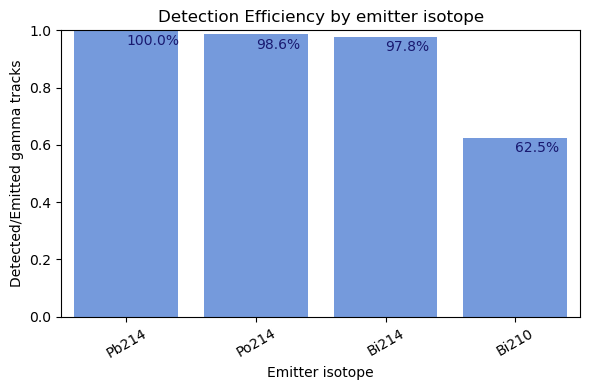

In [85]:
fig, ax = plt.subplots(figsize=(6,4))
bar = sns.barplot(data = efficiency.reset_index(), x='originIsotope', y='efficiency', ax=ax, color='cornflowerblue')
ax.set_title('Detection Efficiency by emitter isotope')
ax.set_xlabel('Emitter isotope')
ax.set_ylabel('Detected/Emitted gamma tracks')
ax.set_ylim(0, min(1.0, efficiency['efficiency'].max() + 1.15))
for idx, row in efficiency.iterrows():
    bar.text(row.name, row.efficiency-0.05, s=str(round(row.efficiency,3)*100)+"%", fontsize='medium', color='midnightblue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [86]:
detector_entries = df[(df['is_detector']) & (df['boundary']=='enter')].copy()

In [92]:
detector_counts = detector_entries.groupby(['originIsotope', 'volumeName']).size().rename('count').reset_index()

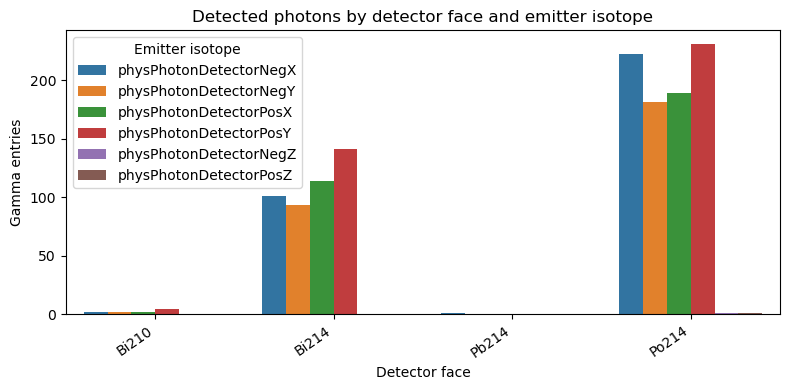

In [95]:
plt.figure(figsize=(8, 4))
sns.barplot(data=detector_counts, x='originIsotope', y='count', hue='volumeName')
plt.title('Detected photons by detector face and emitter isotope')
plt.xlabel('Detector face')
plt.ylabel('Gamma entries')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Emitter isotope')
plt.tight_layout()
plt.show()

In [98]:
sorted(detector_entries['volumeName'].unique())

['physPhotonDetectorNegX',
 'physPhotonDetectorNegY',
 'physPhotonDetectorNegZ',
 'physPhotonDetectorPosX',
 'physPhotonDetectorPosY',
 'physPhotonDetectorPosZ']

In [101]:
face_df = detector_entries[detector_entries['volumeName']=='physPhotonDetectorPosX']

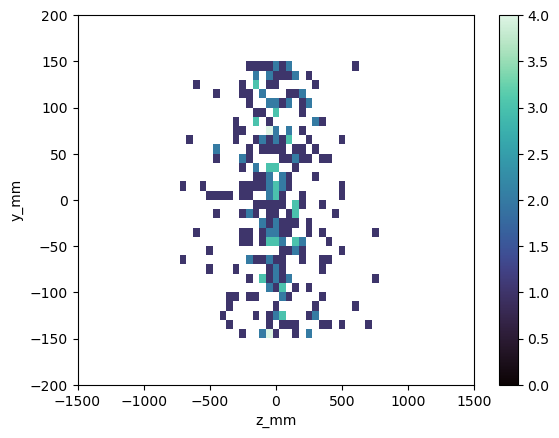

In [103]:
sns.histplot(face_df, x='z_mm', y='y_mm', bins=30, cmap='mako', cbar=True)
plt.xlim(-1500, 1500)
plt.ylim(-200, 200)
plt.show()